<a href="https://colab.research.google.com/github/carlavilla/DataViz2025/blob/main/CV_PS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploring factors that may impact Philadelphia's PIT count
**Research questions:** <br>
- What variables within the current data collection methods of the PIT count appear to impact the accuracy of the count? <br>
- What variables outside of the data collection methods appear to impact the accuracy of the count? <br>

**Background:** <br>
[1](https://www.phila.gov/2022-12-15-the-2023-pit-count-is-coming-what-it-is-why-its-important-and-how-you-can-help/#:~:text=The%20U.S.%20Department%20of%20Housing,in%20January%20every%20other%20year.) The Point-In-Time (PIT) Count is a national count of homeless people across the country. The US Department of Housing and Urban Development (HUD) requires that state and local governments receiving federal funding to address homelessness, known as Continuums of Care or CoC, conduct an annual PIT Count in the month of January. <br>
2 The primary purpose of the PIT Count is to count homeless individuals, with a secondary purpose of collecting demographic information about homeless households (e.g. age, ethnicity, time homeless). There has been criticism about the accuracy of the PIT count. The survey tool is developed by HUD and deployed by each CoC. HUD does **not** require every counted individual to be surveyed. <br>
3  There have been criticisms about the accuracy of the PIT count. Most issues point to discrepancies across data collection methods and conditions outside of the protocol scope that may impact the number of individuals that get counted. Examples include number of counters, weather, hidden sheltering spaces (e.g. cars, abandoned structures), and criminalization of homelessness-adjacent activities.

#Environment set up

In [1]:
#setting up basic libraries
import time, os, sys, re
import zipfile, json, datetime, string
import numpy as np
from statistics import *
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import wb
from pandas.io.formats.style import Styler

In [2]:
#setting up link to online data and Colab
import urllib
from google.colab import files
import seaborn as sns
from google.colab import data_table
data_table.enable_dataframe_formatter()

#Retrieving Data Sets

##Dataset 1: PIT Count
**Description:** Overall count of homeless individuals at PIT counts in Philadelphia, available 2007 to 2023. <br>
**Relevance:** Dependent variable. Starting with overall count but will probably break it into sheltered and unshelterd count or focused on unsheltered. <br>
**Retrieved from:** Downloaded from [HUD PIT and HIC Data reservoir](https://www.hudexchange.info/resource/3031/pit-and-hic-data-since-2007/) on 2/5/2025.<br>
**Format:** .xlsb dataset that allows creation of a subtable. <br>
**Format for analyses:** Subtable was extracted for PA-500 CoC (Philadelphia) as an xlsx file. Data transposed on Excel.

####Dataset Prep (pit)

In [9]:
urllib.request.urlretrieve("https://drive.google.com/uc?id=1Rt9o407BcPjRLF2qzJljDHXqjLjWH0kj&export=download", "HUDPIT_PA500_2007to2023.xlsx")

('HUDPIT_PA500_2007to2023.xlsx', <http.client.HTTPMessage at 0x7a6ad33073d0>)

In [10]:
pit = pd.read_excel('HUDPIT_PA500_2007to2023.xlsx', sheet_name= 'PA500_total')

In [11]:
#checking headers and setting
pit.columns

Index(['year', 'total_count'], dtype='object')

In [17]:
#Renaming for consistency and merging
pit = pit.rename(columns={'year': 'Year'})
pit.columns

Index(['Year', 'total_count'], dtype='object')

####Dataset visual (pit)

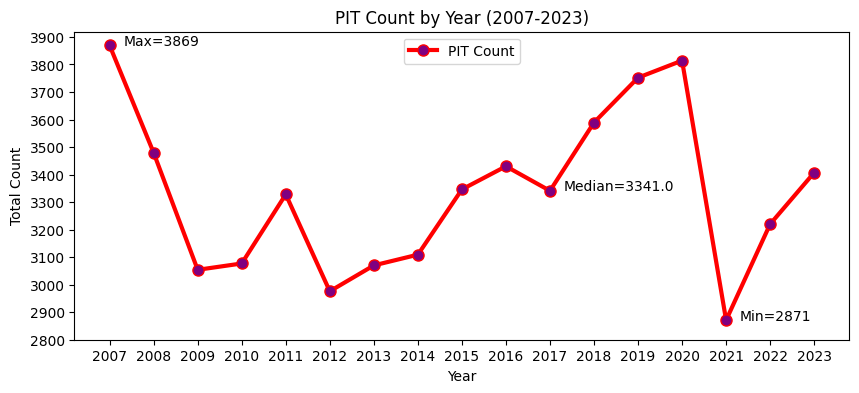

In [102]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot( 'Year', 'total_count', data=pit, marker='o', markerfacecolor='purple', markersize=8, color='red', linewidth=3, label="PIT Count")
ax.legend(loc='upper center')
ax.set_yticks([2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900])
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

medpit=pit.total_count.median()
minpit=pit.total_count.min()
maxpit=pit.total_count.max()
# Find the year corresponding to the median value
median_year = pit.loc[pit['total_count'] == medpit, 'Year'].iloc[0]
minpit_year = pit.loc[pit['total_count'] == minpit, 'Year'].iloc[0]
maxpit_year = pit.loc[pit['total_count'] == maxpit, 'Year'].iloc[0]
# Annotate using the median year and median value
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(10, 0), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Total Count')
plt.title('PIT Count by Year (2007-2023)');

In [44]:
print(pit.total_count.min())
print(pit.total_count.max())
print(pit.total_count.median())

2871
3869
3341.0


##Dataset 2: Temperature
**Description:** Mean for minimum temperature per month 2007-2023. <br>
**Relevance:** Independent variable. Lower temperatures may force homeless people to seek out last-resort informal shelter, reducing overall count. <br>
**Retrieved from:** Downloaded from the [National Weather Service](https://www.weather.gov/wrh/Climate?wfo=phi) on 2/12/2025.<br>
**Format:** data table generated within webpage, available for printing or download as pdf only. <br>
**Format for analyses:** Attempted to read pdf for analyses but could not figure out this time. Ended up converting the pdf to an .xlsx file on Adobe Acrobat. Cleaning of headers on Excel.

####Dataset prep (tempJan)

In [57]:
#retrieving .xlsx document converted on Adobe Acrobat, cleaned on Excel
urllib.request.urlretrieve("https://drive.google.com/uc?id=1myHP4UxOXomqz5JSAYJyo5L3R5v-KW_b&export=download", "min_temp_2007to2023.xlsx")
tempx=pd.read_excel('min_temp_2007to2023.xlsx')

In [60]:
tempx.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'Annual'],
      dtype='object')

In [61]:
tempJan= tempx[['Year','Jan']]

In [138]:
tempJan= tempJan.rename(columns={'Jan': 'Temp'})
tempJan.columns

Index(['Year', 'Temp'], dtype='object')

####Dataset visual (tempJan)

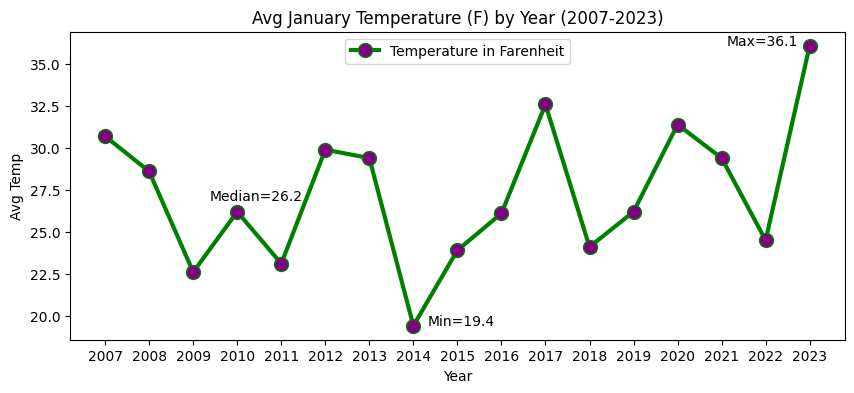

In [139]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot('Year', 'Temp', data=tempJan, marker='o', markerfacecolor='purple', markersize=10, color='green', linewidth=3, label= 'Temperature in Farenheit')
ax.legend(loc='upper center')
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

medtemp=tempJan.Temp.median()
mintemp=tempJan.Temp.min()
maxtemp=tempJan.Temp.max()
# Find the year corresponding to the median value
mediantemp_year = tempJan.loc[tempJan['Temp'] == medtemp, 'Year'].iloc[0]
mintemp_year = tempJan.loc[tempJan['Temp'] == mintemp, 'Year'].iloc[0]
maxtemp_year = tempJan.loc[tempJan['Temp'] == maxtemp, 'Year'].iloc[0]
# Annotate using the median year and median value
ax.annotate(f'Median={medtemp}', (mediantemp_year, medtemp),fontsize=10, xytext=(-20, 8), textcoords='offset points')
ax.annotate(f'Min={mintemp}', (mintemp_year, mintemp),fontsize=10, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxtemp}', (maxtemp_year, maxtemp),fontsize=10, xytext=(-60, 0), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Avg Temp')
plt.title('Avg January Temperature (F) by Year (2007-2023)');

##Dataset 3: Precipitation
**Description:** Mean precipitation for each month 2007-2024. <br>
**Relevance:** Independent variable. Higher precipitation may force homeless people to seek out last-resort informal shelter, reducing overall count. <br>
**Retrieved from:** Downloaded from the [National Weather Service](https://www.weather.gov/wrh/Climate?wfo=phi) on 2/12/2025.<br>
**Format:** data table generated within webpage, available for printing or download as pdf only. <br>
**Format for analyses:** Converted the pdf to an .xlsx file on Adobe Acrobat. Attempting cleaning here.

####Dataset prep (precip5)

In [123]:
#true headers at Index 1, first column not valid
urllib.request.urlretrieve("https://drive.google.com/uc?id=1vm5e50vTZJoyGvA75OtmboqdpHtNWtHA&export=download", "mean_precip_2007to2023.xlsx")
precip = pd.read_excel('mean_precip_2007to2023.xlsx')
precip.head(3)
#you can tell python where the header stars- find command to designate header

,"2/13/25, 12:49 AM about:blank",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,Monthly Mean Precipitation for Philadelphia A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
2,NaN,2007,0.11,0.06,0.12,0.3,0.09,0.13,0.11,0.09,0.02,0.15,0.05,0.14,0.11


In [124]:
#only need data for each year, do not need Index 20 to 24
precip.tail(7)

,"2/13/25, 12:49 AM about:blank",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
18,NaN,2023,0.11,0.05,0.06,0.17,0.01,0.14,0.17,0.1,0.2,0.02,0.09,0.26,0.12
19,NaN,2024,0.19,0.05,0.23,0.14,0.06,0.16,0.08,0.16,0.03,T,0.08,0.11,0.11
20,NaN,Mean,0.1,0.11,0.12,0.13,0.11,0.15,0.15,0.17,0.14,0.11,0.09,0.15,0.13
21,NaN,Max,0.19,0.22,0.24,0.3,0.21,0.35,0.43,0.62,0.34,0.19,0.3,0.29,0.18
22,NaN,NaN,2024,2018,2010,2007,2016,2013,2013,2011,2011,2022,2018,2009,NaN
23,NaN,Min,0.05,0.03,0.03,0.06,0.01,0.06,0.05,0.03,0.02,T,0.02,0.04,0.1
24,NaN,NaN,2021,2009,2012,2016,2023,2017,2012,2015,2007,2024,2021,2017,NaN


In [140]:
precip2= precip.rename(columns={'Unnamed: 1': 'Year', 'Unnamed: 2': 'Precip'})
precip2.head()

,"2/13/25, 12:49 AM about:blank",Year,Precip,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,Monthly Mean Precipitation for Philadelphia A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
2,NaN,2007,0.11,0.06,0.12,0.3,0.09,0.13,0.11,0.09,0.02,0.15,0.05,0.14,0.11
3,NaN,2008,0.06,0.14,0.12,0.07,0.15,0.1,0.11,0.08,0.14,0.05,0.13,0.18,0.11
4,NaN,2009,0.09,0.03,0.05,0.13,0.16,0.16,0.11,0.33,0.12,0.18,0.07,0.29,0.14


In [141]:
#removing irrelevant data
precip3= precip2[['Year', 'Precip']]
precip3.head()


,Year,Precip
0,Monthly Mean Precipitation for Philadelphia A...,NaN
1,Year,Jan
2,2007,0.11
3,2008,0.06
4,2009,0.09


In [142]:
#removing extraneous rows
precip4 = precip3.drop(precip3.index[0:2])
precip4.head()

,Year,Precip
2,2007,0.11
3,2008,0.06
4,2009,0.09
5,2010,0.07
6,2011,0.11


In [143]:
#checking index for tail
precip4.tail(7)

,Year,Precip
18,2023,0.11
19,2024,0.19
20,Mean,0.1
21,Max,0.19
22,NaN,2024
23,Min,0.05
24,NaN,2021


In [144]:
#reseting index so I can delete the correct indeces
precip_reset= precip4.reset_index(drop=True)
precip_reset.tail(7)

,Year,Precip
16,2023,0.11
17,2024,0.19
18,Mean,0.1
19,Max,0.19
20,NaN,2024
21,Min,0.05
22,NaN,2021


In [145]:
#dropping extraneous tail indices
precip5= precip_reset.drop(precip_reset.index[18:])
precip5.tail()

,Year,Precip
13,2020,0.09
14,2021,0.05
15,2022,0.11
16,2023,0.11
17,2024,0.19


In [146]:
precip5.head()

,Year,Precip
0,2007,0.11
1,2008,0.06
2,2009,0.09
3,2010,0.07
4,2011,0.11


####Dataset prep (precip5)

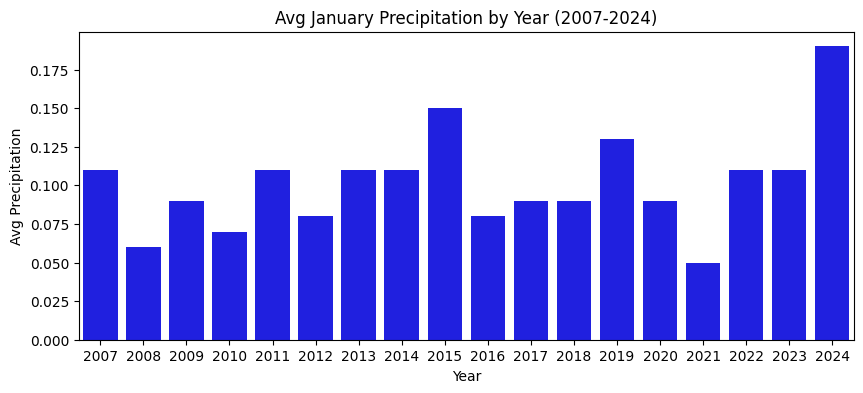

In [147]:
fig, ax = plt.subplots(figsize=(10,4))
ax = sns.barplot(x="Year", y="Precip", data=precip5, estimator=np.mean, errorbar=('ci', 95), capsize=.1, color='blue')
plt.xlabel('Year')
plt.ylabel('Avg Precipitation')
plt.title('Avg January Precipitation by Year (2007-2024)');

##Dataset 4: Demolitions
**Description:** Number of property demolitions initiated in Philadelphia 2007 to 2025. <br>
**Relevance:** Demolition of empty structures may result in fewer informal shelter opportunities for homeless folk, resulting in more visible homeless people during the count in January. <br>
**Retrieved from:** Downloaded from [Open Data Philly](https://opendataphilly.org/datasets/building-demolitions/) on 2/12/2025. <br>
**Format:** csv available on website for download <br>
**Format for analyses:** Demolitions are listed by address so there are multiple entries per year. Created a new sheet and used the Excel CountIf function to count demolitions for each calendar year. Since the demolitions for a given year (e.g. 2007) would hypothetically impact the count in January of the following year (e.g. 2008), a second column was created on Excel as "pit year" to indicate the year the data coulw be relevant for. Since .csv docs do now allow multiple sheets, the spreadsheet was saved as a .xlsx


####Dataset prep (demo3)

In [76]:
import pandas as pd
urllib.request.urlretrieve("https://drive.google.com/uc?id=1i_Uc-gNSdaHFVDcaCbX4o2CN04EvNEx7&export=download", "demolitions_2007to2025.xlsx")
demo=pd.read_excel('demolitions_2007to2025.xlsx', sheet_name='Sheet1')

In [77]:
demo.columns

Index(['year', 'year pit', 'Demolition count'], dtype='object')

In [105]:
demo2 = demo.drop(columns=['year'])
demo2.columns

Index(['year pit', 'Demolition count'], dtype='object')

In [112]:
#renaming year column to prep for merging
#QUESTION: Why do I have to create a new dataframe here whereas I didn't to do that for renaming it in the pit dataframe?
demo3=demo2.rename(columns={'year pit': 'Year'})
demo3.columns

Index(['Year', 'Demolition count'], dtype='object')

In [113]:
demo3=demo3.rename(columns={'Demolition count': 'demos'})
demo3.columns

Index(['Year', 'demos'], dtype='object')

####Dataset visual (demo3)

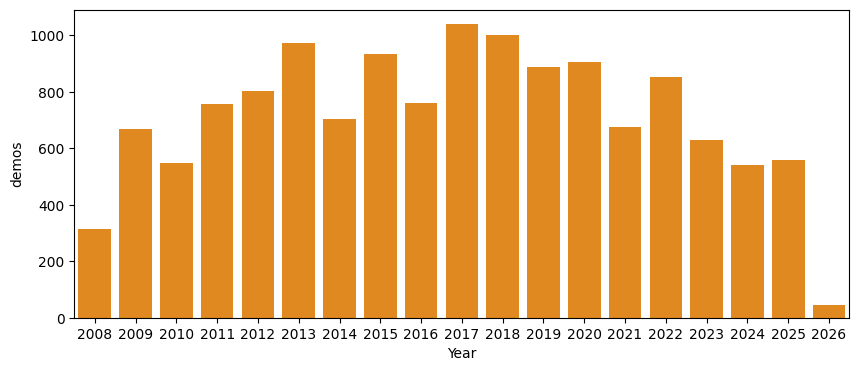

In [134]:
fig, ax = plt.subplots(figsize=(10,4))
ax = sns.barplot(x="Year", y="demos", data=demo3, estimator=np.mean, errorbar=('ci', 95), capsize=.1, color='darkorange')

meddem=demo3.demos.median()
mindem=demo3.demos.min()
maxdem=demo3.demos.max()
meddem_year = demo3.loc[demo3['demos'] == meddem, 'Year'].iloc[0]
mindem_year = demo3.loc[demo3['demos'] == mindem, 'Year'].iloc[0]
maxdem_year = demo3.loc[demo3['demos'] == maxdem, 'Year'].iloc[0]
ax.annotate(f'Median={meddem}', (meddem_year, meddem),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Min={mindem}', (mindem_year, mindem),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Max={maxdem}', (maxdem_year, maxdem),fontsize=10, xytext=(5, 0), textcoords='offset points');
#ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
               # ha='center', va='center', xytext=(0, 8), textcoords='offset points')


#Merging Datasets


In [174]:
merged_df = pd.merge(pit, tempJan, on='Year', how='outer', indicator='merged')
merged_df

,Year,total_count,Temp,merged
0,2007,3869,30.7,both
1,2008,3479,28.6,both
2,2009,3054,22.6,both
3,2010,3077,26.2,both
4,2011,3328,23.1,both
5,2012,2976,29.9,both
6,2013,3070,29.4,both
7,2014,3109,19.4,both
8,2015,3346,23.9,both
9,2016,3430,26.1,both


In [175]:
merged_df['merged'].value_counts()

,count
merged,
both,17
left_only,0
right_only,0


In [176]:
merged_df = pd.merge(merged_df, precip5, on='Year', how='outer', indicator='merged2')
merged_df

,Year,total_count,Temp,merged,Precip,merged2
0,2007,3869.0,30.7,both,0.11,both
1,2008,3479.0,28.6,both,0.06,both
2,2009,3054.0,22.6,both,0.09,both
3,2010,3077.0,26.2,both,0.07,both
4,2011,3328.0,23.1,both,0.11,both
5,2012,2976.0,29.9,both,0.08,both
6,2013,3070.0,29.4,both,0.11,both
7,2014,3109.0,19.4,both,0.11,both
8,2015,3346.0,23.9,both,0.15,both
9,2016,3430.0,26.1,both,0.08,both


In [177]:
merged_df['merged2'].value_counts()

,count
merged2,
both,17
right_only,1
left_only,0


In [179]:
pitmerged= pd.merge(merged_df, demo3, on='Year', how='outer', indicator='merged3')
pitmerged

,Year,total_count,Temp,merged,Precip,merged2,demos,merged3
0,2007,3869.0,30.7,both,0.11,both,NaN,left_only
1,2008,3479.0,28.6,both,0.06,both,315.0,both
2,2009,3054.0,22.6,both,0.09,both,667.0,both
3,2010,3077.0,26.2,both,0.07,both,548.0,both
4,2011,3328.0,23.1,both,0.11,both,758.0,both
5,2012,2976.0,29.9,both,0.08,both,803.0,both
6,2013,3070.0,29.4,both,0.11,both,974.0,both
7,2014,3109.0,19.4,both,0.11,both,703.0,both
8,2015,3346.0,23.9,both,0.15,both,935.0,both
9,2016,3430.0,26.1,both,0.08,both,762.0,both


In [180]:
pitmerged['merged3'].value_counts()

,count
merged3,
both,17
right_only,2
left_only,1


#Visuals Merged Dataset (pitmerged)

**Goal:** Plotting variables to check for potential autocorrelations. Autocorrelations would indicate that two independent variables are related, and this could impact how each of these variables' relationship to the dependable variable (PIT count) is interpreted.

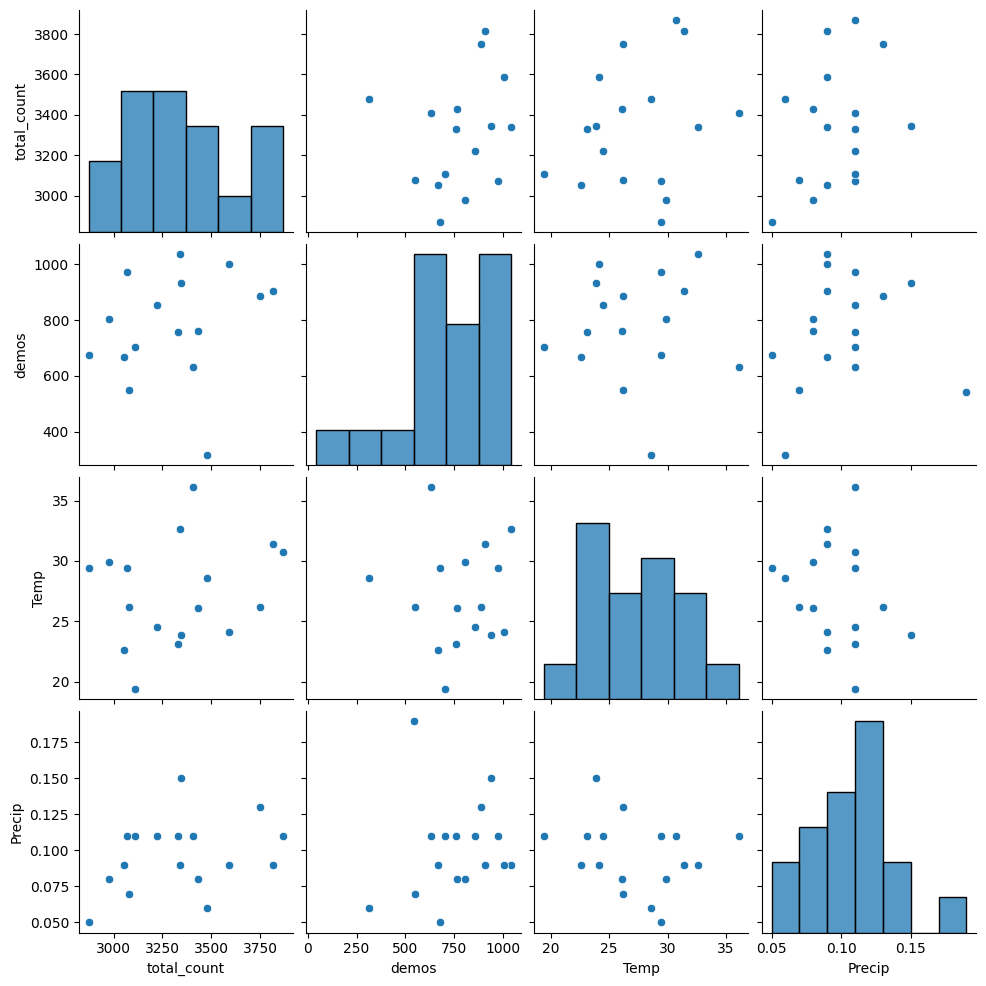

In [189]:
#corr matrix
sns.pairplot(pitmerged[['total_count','demos','Temp','Precip']]) #,height=2,aspect=1

**Scatter Plot Interpretation:** Scatterplots do not suggest any strong correlations between independent variables.

**Hypothesis:** There will be a positive correlation between the number of demolitions started within a given calendar year and the following year's overrall PIT count.

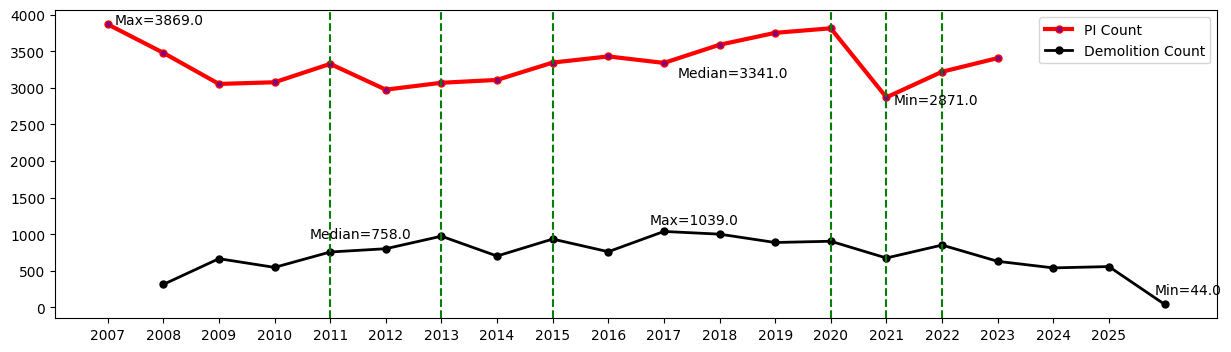

In [234]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'total_count', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='red', linewidth=3, label="PI Count")
ax.plot( 'Year', 'demos', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Demolition Count")
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
# plot descriptives Pit
medpit=pitmerged.total_count.median()
minpit=pitmerged.total_count.min()
maxpit=pitmerged.total_count.max()
median_year = pitmerged.loc[pitmerged['total_count'] == medpit, 'Year'].iloc[0]
minpit_year = pitmerged.loc[pitmerged['total_count'] == minpit, 'Year'].iloc[0]
maxpit_year = pitmerged.loc[pitmerged['total_count'] == maxpit, 'Year'].iloc[0]
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(5, -5), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
# plot descriptives demos
meddem=pitmerged.demos.median()
mindem=pitmerged.demos.min()
maxdem=pitmerged.demos.max()
meddem_year = pitmerged.loc[pitmerged['demos'] == meddem, 'Year'].iloc[0]
mindem_year = pitmerged.loc[pitmerged['demos'] == mindem, 'Year'].iloc[0]
maxdem_year = pitmerged.loc[pitmerged['demos'] == maxdem, 'Year'].iloc[0]
ax.annotate(f'Median={meddem}', (meddem_year, meddem),fontsize=10, xytext=(-15, 10), textcoords='offset points')
ax.annotate(f'Min={mindem}', (mindem_year, mindem),fontsize=10, xytext=(-7, 7), textcoords='offset points')
ax.annotate(f'Max={maxdem}', (maxdem_year, maxdem),fontsize=10, xytext=(-10, 5), textcoords='offset points')
#plot visual notes
ax.axvline(2011, color="green", ls="--")
ax.axvline(2013, color="green", ls="--")
ax.axvline(2015, color="green", ls="--")
ax.axvline(2020, color="green", ls="--")
ax.axvline(2021, color="green", ls="--")
ax.axvline(2022, color="green", ls="--")
ax.legend();

**Interpretation:** Hypothesis not supported. There appears to be no relationship between the number of demolitions in a given calendar year and the following year's overall PIT count. This line graph does not suggest a strong pattern between overall PIT count and new demolitions within the 12 months prior to a corresponding year. There are weak patterns of increasing numbers in years 2011, 2013, 2015, 2020, and 2022. Both numbers decreased in the year 2021. Although the smaller scale of demolition counts may be downplaying the similarity in trends, the changes in numbers do not appear proportional at first glance. Furthermore, similarities in year 2021 and 2022 may be related to pandemic policies, such as moratoriums on evictions and delays in construction projects. <br>
However, the demolition of properties would affect unsheltered individuals more than sheltered homeless people. Given that the overall PIT count includes both sheltered and unsheltered homeless people, it is possible that the total count is not reflecting the changes as much as the number of unsheltered people would. <br>
**Next steps:** compare with number of unsheltered PIT numbers.

**Goal:** Given that both Temperature and Precipitation are weather-related variables, we are running an additional comparison to examines if there are any similarities between these two variables.<br>
*Additional data manipulation:* Given that precipitation is such a small unit, the number was multiplied by 100 to create a comparable scale with temperature.

In [220]:
pitmerged['bigprecip'] = pitmerged['Precip'] * 100

In [221]:
df = pitmerged[['Year','Temp','bigprecip']].set_index('Year')
ind_list = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
df=df.loc[ind_list]

In [217]:
df[:].style.background_gradient(cmap="coolwarm")

,Temp,bigprecip
Year,,
2007,30.700000,11.000000
2008,28.600000,6.000000
2009,22.600000,9.000000
2010,26.200000,7.000000
2011,23.100000,11.000000
2012,29.900000,8.000000
2013,29.400000,11.000000
2014,19.400000,11.000000
2015,23.900000,15.000000


**Interpretation:** Even when converted, precipitation was still too small for this visual to pick up on similarities between increasing and decreasing values. However, there does not seem to be a correlation between these two variables.

**Hypothesis:** There will be a negative correlation between the overall PIT count and the average temperature for the month of January each year. <br>
*Additional data manipulation:* Given that the PIT count is such a larger scale, the number was divided by 100 to create a comparable scale with temperature.

In [205]:
pitmerged['shortpit'] = pitmerged['total_count'] / 100

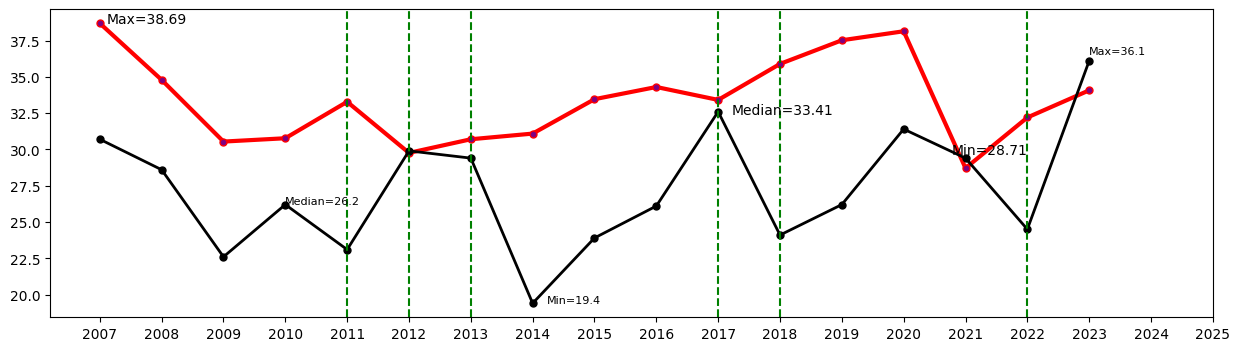

In [213]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'shortpit', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='red', linewidth=3, label="PI Count")
ax.plot( 'Year', 'Temp', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Temp(F)")
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
# plot descriptives Pit
medpit=pitmerged.shortpit.median()
minpit=pitmerged.shortpit.min()
maxpit=pitmerged.shortpit.max()
median_year = pitmerged.loc[pitmerged['shortpit'] == medpit, 'Year'].iloc[0]
minpit_year = pitmerged.loc[pitmerged['shortpit'] == minpit, 'Year'].iloc[0]
maxpit_year = pitmerged.loc[pitmerged['shortpit'] == maxpit, 'Year'].iloc[0]
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(-10, 10), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
# plot descriptives Temp
medtemp=pitmerged.Temp.median()
mintemp=pitmerged.Temp.min()
maxtemp=pitmerged.Temp.max()
mediantemp_year = pitmerged.loc[pitmerged['Temp'] == medtemp, 'Year'].iloc[0]
mintemp_year = pitmerged.loc[pitmerged['Temp'] == mintemp, 'Year'].iloc[0]
maxtemp_year = pitmerged.loc[pitmerged['Temp'] == maxtemp, 'Year'].iloc[0]
ax.annotate(f'Median={medtemp}', (mediantemp_year, medtemp),fontsize=8, xytext=(0, 0), textcoords='offset points')
ax.annotate(f'Min={mintemp}', (mintemp_year, mintemp),fontsize=8, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxtemp}', (maxtemp_year, maxtemp),fontsize=8, xytext=(0, 5), textcoords='offset points')
#plot visual notes
ax.axvline(2011, color="green", ls="--")
ax.axvline(2012, color="green", ls="--")
ax.axvline(2013, color="green", ls="--")
ax.axvline(2017, color="green", ls="--")
ax.axvline(2018, color="green", ls="--")
ax.axvline(2022, color="green", ls="--")

**Interpretation:** There may be some evidence to support this hypothesis. The line graph suggest a possible pattern between overall PIT count and average temperature in a given year. Decreasing temperatures coincided with increasing overall PIT numbers in years 2011, 2013, 2018, and 2022. Decreasing overall PIT numbers coincided with increasing temperatures in years 2012 and 2017. <br>
However, changes in temperature might affect sheltered and unsheltered homeless numbers differently. <br>
**Next steps:** compare with number of unsheltered and sheltered PIT numbers separately.

**Hypothesis:** There will be a negative correlation between the overall PIT count numbers and the average precipitation for january each year.

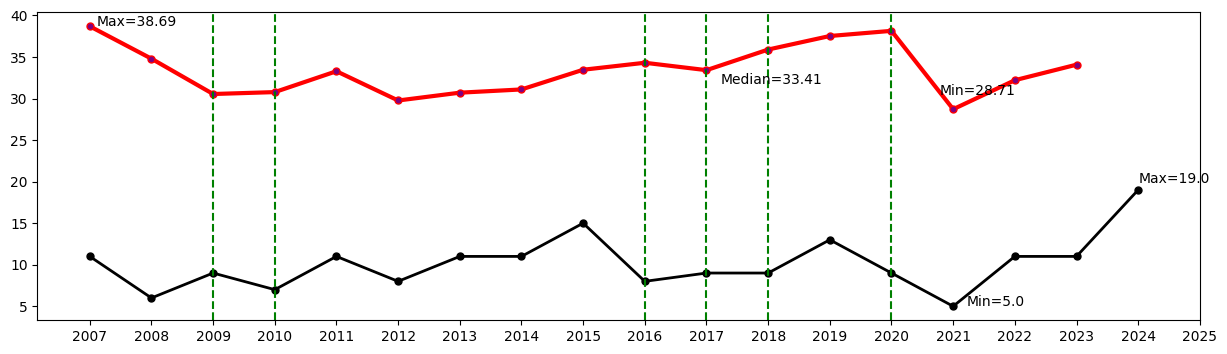

In [233]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'shortpit', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='red', linewidth=3, label="PI Count")
ax.plot( 'Year', 'bigprecip', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Temp(F)")
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
# plot descriptives Pit
medpit=pitmerged.shortpit.median()
minpit=pitmerged.shortpit.min()
maxpit=pitmerged.shortpit.max()
median_year = pitmerged.loc[pitmerged['shortpit'] == medpit, 'Year'].iloc[0]
minpit_year = pitmerged.loc[pitmerged['shortpit'] == minpit, 'Year'].iloc[0]
maxpit_year = pitmerged.loc[pitmerged['shortpit'] == maxpit, 'Year'].iloc[0]
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(-10, 10), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
# plot descriptives Precipitation
#medpre=pitmerged.bigprecip.median()
minpre=pitmerged.bigprecip.min()
maxpre=pitmerged.bigprecip.max()
#medpre_year = pitmerged.loc[pitmerged['bigprecip'] == medpre, 'Year'].iloc[0]
minpre_year = pitmerged.loc[pitmerged['bigprecip'] == minpre, 'Year'].iloc[0]
maxpre_year = pitmerged.loc[pitmerged['bigprecip'] == maxpre, 'Year'].iloc[0]
#ax.annotate(f'Median={medpre}', (medpre_year, medpre),fontsize=10, xytext=(0, 0), textcoords='offset points')
ax.annotate(f'Min={minpre}', (minpre_year, minpre),fontsize=10, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxpre}', (maxpre_year, maxpre),fontsize=10, xytext=(0, 5), textcoords='offset points')
#plot visual notes
ax.axvline(2009, color="green", ls="--")
ax.axvline(2010, color="green", ls="--")
ax.axvline(2016, color="green", ls="--")
ax.axvline(2017, color="green", ls="--")
ax.axvline(2018, color="green", ls="--")
ax.axvline(2020, color="green", ls="--")

**Interpretation:** There may be some evidence to support this hypothesis. The line graph suggest a slight pattern between overall PIT count and average January precipitation in a given year. Increasing precipitation averages coincided with decreasing overall PIT numbers in years 2009 and 2017. Increasing overall PIT numbers coincided with decreasing precipitation averages in years 2010, 2016, 2018 and 2020. <br>
However, changes in precipitation might affect sheltered and unsheltered homeless numbers differently. <br>
**Next steps:** Compare with number of unsheltered and sheltered PIT numbers separately.

In [228]:
print(pitmerged.bigprecip.median())
#QUESTION: Did not include precipitation median as there is no corresponding year for it.

10.0


In [226]:
print(pitmerged.bigprecip)

0     11.0
1      6.0
2      9.0
3      7.0
4     11.0
5      8.0
6     11.0
7     11.0
8     15.0
9      8.0
10     9.0
11     9.0
12    13.0
13     9.0
14     5.0
15    11.0
16    11.0
17    19.0
18     NaN
19     NaN
Name: bigprecip, dtype: object
